Project Setup and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(".")
data_path = BASE_DIR / "data.csv"

df = pd.read_csv(data_path)
df.head()


,date,category,amount,notes
0,2026-01-14,Food,12.5,lunch
1,2026-01-14,Transport,3.0,taxi
2,2026-01-15,Internet,8.0,monthly
3,2026-01-15,Food,6.0,coffee
4,2026-01-16,Other,2.5,snack


Clean and Prepare the Data

In [2]:
df.columns = [c.strip().lower() for c in df.columns]

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

df = df.dropna(subset=["date", "category", "amount"])

df["category"] = df["category"].astype(str).str.strip()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      10 non-null     datetime64[ns]
 1   category  10 non-null     object        
 2   amount    10 non-null     float64       
 3   notes     10 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 452.0+ bytes


Calculate Key Metrics (KPIs)

In [3]:
total = df["amount"].sum()
avg = df["amount"].mean()
max_exp = df["amount"].max()
min_exp = df["amount"].min()
count_rows = len(df)

print("Rows:", count_rows)
print("Total amount:", round(total, 2))
print("Average expense:", round(avg, 2))
print("Highest expense:", round(max_exp, 2))
print("Lowest expense:", round(min_exp, 2))


Rows: 10
Total amount: 72.5
Average expense: 7.25
Highest expense: 15.0
Lowest expense: 2.5


Apply a Filter (Example: Food Category Only)

In [4]:
food_df = df[df["category"].str.lower() == "food"]
food_df


,date,category,amount,notes
0,2026-01-14,Food,12.5,lunch
3,2026-01-15,Food,6.0,coffee
5,2026-01-16,Food,15.0,dinner
7,2026-01-17,Food,9.0,breakfast
9,2026-01-19,Food,7.5,tea


Top 5 Highest Expenses

In [5]:
top5 = df.sort_values("amount", ascending=False).head(5)
top5


,date,category,amount,notes
5,2026-01-16,Food,15.0,dinner
0,2026-01-14,Food,12.5,lunch
7,2026-01-17,Food,9.0,breakfast
2,2026-01-15,Internet,8.0,monthly
9,2026-01-19,Food,7.5,tea


Create One Chart (Total Expenses by Category)

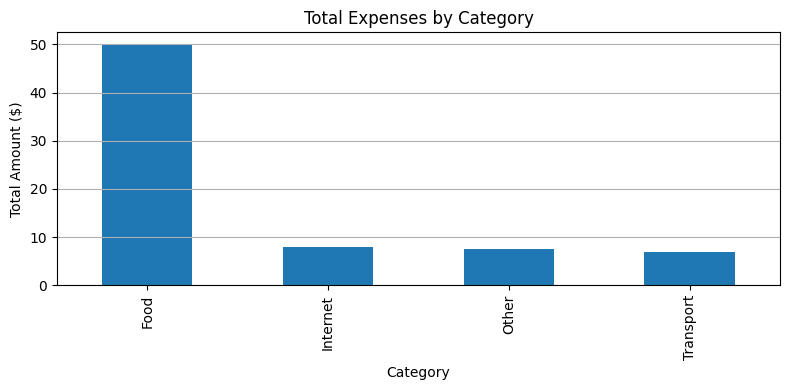

In [6]:
summary_cat = df.groupby("category")["amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
summary_cat.plot(kind="bar")

plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount ($)")
plt.grid(True, axis="y")

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()


Write a Report File (5 Lines)

In [7]:
top_category = summary_cat.index[0]
top_category_value = summary_cat.iloc[0]

report_lines = [
    f"Rows: {count_rows}",
    f"Total amount: {total:.2f}",
    f"Average expense: {avg:.2f}",
    f"Highest expense: {max_exp:.2f}",
    f"Top category: {top_category} ({top_category_value:.2f})"
]

report_path = BASE_DIR / "report.txt"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved report.txt")
print(report_path.read_text(encoding="utf-8"))


Saved report.txt
Rows: 10
Total amount: 72.50
Average expense: 7.25
Highest expense: 15.00
Top category: Food (50.00)
